In [16]:
import pandas as pd
import numpy as np
import sklearn

from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer

import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("patient_health_data_1000.csv")
df.head()


,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P10000,56.0,Male,South,25.47,126.23,223.20,52.14,1
1,P10001,69.0,Female,North,31.48,110.34,221.74,38.83,0
2,P10002,46.0,Male,South,33.56,137.28,172.20,63.13,1
3,P10003,32.0,Female,North,32.85,147.33,198.89,133.69,0
4,P10004,60.0,Female,North,21.83,95.96,221.89,123.40,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   patient_id      1000 non-null   str    
 1   age             950 non-null    float64
 2   gender          960 non-null    str    
 3   region          956 non-null    str    
 4   bmi             960 non-null    float64
 5   blood_pressure  1000 non-null   float64
 6   cholesterol     960 non-null    float64
 7   glucose         960 non-null    float64
 8   disease_risk    1000 non-null   int64  
dtypes: float64(5), int64(1), str(3)
memory usage: 70.4 KB


In [4]:
df.describe()

,age,bmi,blood_pressure,cholesterol,glucose,disease_risk
count,950.000000,960.000000,1000.000000,960.000000,960.000000,1000.00000
mean,49.956842,25.734938,120.996730,198.042198,101.380854,0.45500
std,18.200477,6.724273,18.127763,38.333926,32.418558,0.49822
min,18.000000,7.430000,71.410000,51.650000,8.070000,0.00000
25%,35.000000,21.645000,110.210000,172.460000,79.150000,0.00000
50%,50.000000,25.780000,120.035000,198.965000,102.045000,0.00000
75%,66.000000,29.427500,130.507500,223.115000,122.642500,1.00000
max,79.000000,63.360000,260.802000,310.650000,334.000000,1.00000


In [5]:
df.isnull().sum()

patient_id         0
age               50
gender            40
region            44
bmi               40
blood_pressure     0
cholesterol       40
glucose           40
disease_risk       0
dtype: int64

# Part A: Handling Missing Values

In [14]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

missing_summary

,missing_count,missing_percent
patient_id,0,0.0
age,50,5.0
gender,40,4.0
region,44,4.4
bmi,40,4.0
blood_pressure,0,0.0
cholesterol,40,4.0
glucose,40,4.0
disease_risk,0,0.0


In [17]:
df_simple = df.copy()

num_imputer_mean = SimpleImputer(strategy="mean")
df_simple[["bmi"]] = num_imputer_mean.fit_transform(df_simple[["bmi"]])

df_simple.isna().sum()


patient_id         0
age               50
gender            40
region            44
bmi                0
blood_pressure     0
cholesterol       40
glucose           40
disease_risk       0
dtype: int64

In [18]:
cat_imputer = SimpleImputer(strategy="most_frequent")
df_simple[["region"]] = cat_imputer.fit_transform(df_simple[["region"]])

df_simple.isna().sum()

patient_id         0
age               50
gender            40
region             0
bmi                0
blood_pressure     0
cholesterol       40
glucose           40
disease_risk       0
dtype: int64

In [27]:
df_knn = df.copy()

num_cols = ["age", "bmi", "cholesterol", "glucose", "blood_pressure"]

knn_imputer = KNNImputer(n_neighbors=5)
df_knn[num_cols] = knn_imputer.fit_transform(df_knn[num_cols])

df_knn.isna().sum()

patient_id         0
age                0
gender            40
region            44
bmi                0
blood_pressure     0
cholesterol        0
glucose            0
disease_risk       0
dtype: int64

In [28]:
df_mice = df.copy()

mice_imputer = IterativeImputer(random_state=42)
df_mice[num_cols] = mice_imputer.fit_transform(df_mice[num_cols])

df_mice.isna().sum()

patient_id         0
age                0
gender            40
region            44
bmi                0
blood_pressure     0
cholesterol        0
glucose            0
disease_risk       0
dtype: int64

# Part B: Handling Outliers

In [21]:
print(df[["cholesterol", "glucose"]].head())

   cholesterol  glucose
0       223.20    52.14
1       221.74    38.83
2       172.20    63.13
3       198.89   133.69
4       221.89   123.40


In [24]:
z_scores = np.abs(zscore(df[["cholesterol", "glucose"]]))

df_z = df[(z_scores < 3).all(axis=1)]

print("Original shape:", df.shape)
print("After removing outliers:", df_z.shape)

Original shape: (1000, 9)
After removing outliers: (0, 9)


In [29]:

df_outliers = df_mice.copy()

Q1 = df_outliers["bmi"].quantile(0.25)
Q3 = df_outliers["bmi"].quantile(0.75)
IQR = Q3 - Q1

df_iqr = df_outliers[
    (df_outliers["bmi"] >= Q1 - 1.5 * IQR) &
    (df_outliers["bmi"] <= Q3 + 1.5 * IQR)
]

df_iqr.shape

(976, 9)

In [33]:
# Select only numeric columns
df_numeric = df_outliers.select_dtypes(include='number')

lower = df_numeric.quantile(0.01)
upper = df_numeric.quantile(0.99)

df_percentile = df_numeric.clip(lower=lower, upper=upper, axis=1)

df_percentile.describe()


,age,bmi,blood_pressure,cholesterol,glucose,disease_risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,49.956648,25.652202,120.589956,198.061642,101.063042,0.45500
std,17.739208,6.153995,15.754530,36.784416,29.824888,0.49822
min,18.000000,10.747900,84.999300,103.029400,30.834900,0.00000
25%,36.000000,21.937500,110.210000,174.067500,80.215000,0.00000
50%,50.000000,25.761810,120.035000,198.169481,101.536057,0.00000
75%,65.250000,29.252500,130.507500,222.062500,121.367500,1.00000
max,79.000000,43.730500,174.980340,287.473000,177.098400,1.00000


In [37]:
from scipy.stats.mstats import winsorize

df_winsor = df_outliers.copy()

for col in ["bmi", "cholesterol", "glucose", "blood_pressure"]:
    df_winsor[col] = winsorize(df_winsor[col], limits=[0.01, 0.01])
df_winsor.describe()

c:\tanish\data pre\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\tanish\data pre\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\tanish\data pre\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(
c:\tanish\data pre\.venv\Lib\site-packages\numpy\lib\_function_base_impl.py:4786: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  arr.partition(


,age,bmi,blood_pressure,cholesterol,glucose,disease_risk
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000
mean,49.956648,25.652218,120.588860,198.061718,101.063009,0.45500
std,17.739208,6.153929,15.750705,36.782062,29.824553,0.49822
min,18.000000,10.750000,85.000000,103.080000,30.840000,0.00000
25%,36.000000,21.937500,110.210000,174.067500,80.215000,0.00000
50%,50.000000,25.761810,120.035000,198.169481,101.536057,0.00000
75%,65.250000,29.252500,130.507500,222.062500,121.367500,1.00000
max,79.000000,43.730000,174.870000,287.430000,177.090000,1.00000



# Part C: Final Clean Dataset

In [38]:
final_df = df_winsor.copy()

final_df.isna().sum()

patient_id         0
age                0
gender            40
region            44
bmi                0
blood_pressure     0
cholesterol        0
glucose            0
disease_risk       0
dtype: int64

In [40]:
final_df.to_csv("final_clean_patient_data.csv", index=False)

final_df.head()

,patient_id,age,gender,region,bmi,blood_pressure,cholesterol,glucose,disease_risk
0,P10000,56.0,Male,South,25.47,126.23,223.20,52.14,1
1,P10001,69.0,Female,North,31.48,110.34,221.74,38.83,0
2,P10002,46.0,Male,South,33.56,137.28,172.20,63.13,1
3,P10003,32.0,Female,North,32.85,147.33,198.89,133.69,0
4,P10004,60.0,Female,North,21.83,95.96,221.89,123.40,0


In [43]:
import seaborn as sns

Index(['patient_id', 'age', 'gender', 'region', 'bmi', 'blood_pressure',
       'cholesterol', 'glucose', 'disease_risk'],
      dtype='str')


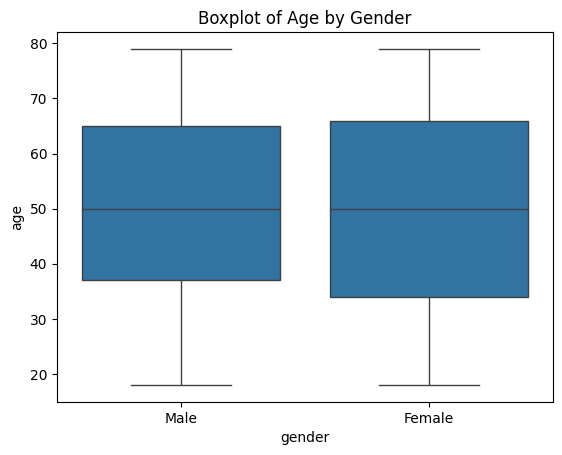

In [44]:
df = pd.read_csv("final_clean_patient_data.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

print(df.columns)

sns.boxplot(x="gender", y="age", data=df)
plt.title("Boxplot of Age by Gender")
plt.show()
